In [16]:
!pip install ipython matplotlib mne numpy pandas scikit_learn seaborn sktime numba

  Using cached llvmlite-0.46.0-cp310-cp310-win_amd64.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 13.3 MB/s  0:00:00
Using cached llvmlite-0.46.0-cp310-cp310-win_amd64.whl (38.1 MB)

   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   ---------------------------------------- 0/2 [llvmlite]
   -------------------- ------------------- 1/2 [numba]
   -------------------- ------------------- 1/2 [numba]
   -------------------- ------------------- 1/2 [numba]
   -------------------- ------------------- 1/2 [numba]
   -------------------- ------------------- 1/2 [numba]
   -------------------- ------------------- 1/2 [numba]
   -------------------- --

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from IPython.display import display
%matplotlib inline

import mne
from mne.datasets import eegbci, sample, erp_core
from mne.io import read_raw_edf, concatenate_raws
from mne.time_frequency import psd_array_welch
from mne.decoding import CSP

from sklearn.model_selection import cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn import metrics
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.ensemble import RandomForestClassifier
from sktime.transformations.panel.rocket import Rocket
from sktime.classification.kernel_based import RocketClassifier

In [2]:
# Частота для ресемплинга
sfreq = 160
# Количество испытуемых (для датасета bci)
n_sub = 5

le = LabelEncoder()

### Конвертер данных для sktime
Преобразует 3D массив (эпохи, каналы, время) в формат pd.DataFrame для sktime

In [3]:
class SktimeConverter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        n_epochs, n_channels, n_times = X.shape
        cols = [f"ch{i}" for i in range(n_channels)]
        return pd.DataFrame({
            cols[i]: [pd.Series(X[j, i, :]) for j in range(n_epochs)]
            for i in range(n_channels)
        })

### Функция визуализации матрицы ошибок

In [4]:
def show_confusion_matrix(y_encoded, y_pred, display_labels, name, dataset_id):
    plt.figure(figsize=(6, 4))
    sns.heatmap(metrics.confusion_matrix(y_encoded, y_pred), annot=True, fmt='d', cmap='Blues',
                yticklabels=display_labels)
    plt.title(f"Матрица ошибок | Модель: {name} | Датасет: {dataset_id}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

### Гибридный экстрактор
Объединяет спектральную мощность (частотный домен) и признаки ROCKET (временной домен)

In [5]:
class EEGHybridExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, num_kernels=200, sfreq=sfreq):
        self.num_kernels = num_kernels
        self.sfreq = sfreq
        self.rocket = Rocket(num_kernels=self.num_kernels, random_state=42)
        self.scaler = StandardScaler()
        self.converter = SktimeConverter()

    def _get_band_power(self, X):
        # Расчет мощности классических ритмов ЭЭГ через метод Велча
        nyquist = self.sfreq / 2
        f_limit = min(40, nyquist - 1)
        
        n_fft = min(256, X.shape[-1])
        psds, freqs = psd_array_welch(
            X, sfreq=self.sfreq, fmin=1, fmax=f_limit, 
            n_fft=n_fft, n_overlap=n_fft//2, verbose=False
        )
        
        bands = {"delta": (1, 4), "theta": (4, 7), "alpha": (7, 14), 
                 "beta": (14, 30), "gamma": (30, f_limit)}
        
        out = []
        for band, (fmin, fmax) in bands.items():
            idx = np.logical_and(freqs >= fmin, freqs <= fmax)
            power = psds[:, :, idx].mean(axis=-1) 
            power = 10 * np.log10(psds[:, :, idx].mean(axis=-1) + 1e-20)
            out.append(power)
        
        return np.concatenate(out, axis=1)
    def _combine_features(self, X):
        X_df = self.converter.transform(X)
        X_rocket = self.rocket.transform(X_df)
        X_bp = self._get_band_power(X)
        return np.concatenate([X_bp, np.asarray(X_rocket)], axis=1)
        
    def fit(self, X, y=None):
        X_df = self.converter.transform(X)
        self.rocket.fit(X_df)
        X_combined = self._combine_features(X)
        self.scaler.fit(X_combined)
        return self
        
    def transform(self, X):
        X_combined = self._combine_features(X)
        return self.scaler.transform(X_combined)

## Загрузка ДАТАСЕТА

Подгружаем сырые данные (Raw). Разные датасеты имеют свою специфику: EEG BCI фокусируется на моторном воображении (представлении движений), MNE Sample — на первичных сенсорных ответах (слух/зрение), а ERP Core — на когнитивном контроле (задача Фланкера). Переименование каналов и установка стандартного монтажа (10-20) необходимы для корректной пространственной локализации электродов

In [6]:
def load_selected_dataset(choice):
    match choice:
        case 1:
            print("Загрузка EEG BCI")
            subjects = range(1, n_sub + 1)
            runs = [3, 7, 11]
            all_raws = []
            for s in subjects:
                fnames = eegbci.load_data(s, runs)
                all_raws.extend([mne.io.read_raw_edf(f, preload=True) for f in fnames])
            raw = mne.concatenate_raws(all_raws)
            raw.rename_channels(lambda x: x.strip('.').replace('Z', 'z').replace('FP', 'Fp'))
            raw.set_montage('standard_1020', on_missing='ignore')
        case 2:
            print("Загрузка MNE Sample")
            data_path = sample.data_path()
            raw_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
            raw = mne.io.read_raw_fif(raw_fname, preload=True)
            raw.pick(['eeg', 'stim'])
            
        case 3:
            print("Загрузка ERP Core")
            raw_fname = erp_core.data_path() / f'ERP-CORE_Subject-001_Task-Flankers_eeg.fif'
            raw = mne.io.read_raw_fif(raw_fname, preload=True)
            raw.pick(['eeg', 'stim'])
        case _:
            raise ValueError("Не существует")
    
    return raw

## Функция ICA
Разбиваем многоканальный сигнал на статистически независимые источники и удаляем те, что похожи на моргание глаз. Глазные яблоки — это диполи. При моргании они создают мощный электрический импульс, который "забивает" сигналы мозга. ICA (Independent Component Analysis) позволяет отделить сигнал "моргания" от "мыслей", не удаляя при этом полезные данные из самих каналов.

In [7]:
def apply_ica(raw, n_components=20, random_state=42, threshold=2.5):
    raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
    n_channels = len(raw_for_ica.ch_names)
    n_components = min(n_components, n_channels - 1)
    ica = mne.preprocessing.ICA(
        n_components=n_components, 
        random_state=random_state, 
        method='fastica',
        max_iter='auto'
    )
    ica.fit(raw_for_ica, verbose=False)
    # Список каналов с потенциальным морганием
    candidate_eog = ['Fp1', 'Fp2', 'FP1', 'FP2', 'EEG 001']
    # Находим существующие в датасете
    eog_ch = [ch for ch in candidate_eog if ch in raw_for_ica.ch_names]
    if eog_ch:
        # Используем первый найденный лобный канал как референс для поиска морганий
        eog_indices, eog_scores = ica.find_bads_eog(
            raw_for_ica, 
            ch_name=eog_ch[0], 
            threshold=threshold,
            verbose=False
        )
        ica.exclude = eog_indices
    else:
        ica.exclude = []
    raw_clean = ica.apply(raw.copy(), verbose=False)
    return raw_clean

## Функция разделения на эпохи
Нарезаем непрерывную запись на короткие эпохи вокруг событий. В ЭЭГ нас интересует реакция на конкретное событие. Мы берем окно (например, от -0.2 до 0.8 сек), где 0 — момент стимула. Baseline correction вычитает среднее значение "пред-стимульного" периода, чтобы скомпенсировать возможный сдвиг напряжения в момент записи.

In [8]:
def epochs_from_raw(raw, tmin=-0.2, tmax=0.8, event_id=None, picks='data', events=None):
    if events is None:
        events, _ = mne.events_from_annotations(raw, verbose=False)
        if len(events) == 0:
            events = mne.find_events(raw, stim_channel='STI 014', verbose=False)

    unique, counts = np.unique(events[:, -1], return_counts=True)
    valid_classes = unique[counts > 5]
    events = events[np.isin(events[:, -1], valid_classes)]
    
    raw_proc = raw.copy()
    raw_proc.filter(1, 40, fir_design='firwin', picks='data', verbose=False)
    if raw_proc.info['sfreq'] > sfreq:
        raw_proc.resample(sfreq, verbose=False)
    raw_proc.set_eeg_reference('average', projection=False, verbose=False)

    raw_clean = apply_ica(raw_proc)
    
    epochs = mne.Epochs(
        raw_clean, 
        events=events, 
        event_id=event_id,
        tmin=tmin, 
        tmax=tmax,
        baseline=(None, 0),
        preload=True,
        reject=dict(eeg=150e-6),
        flat=dict(eeg=1e-6),
        verbose=False
    )

    X = epochs.get_data(picks=picks) * 1e6
    y = epochs.events[:, -1]

    print(f"Всего эпох после фильтрации: {len(epochs)}")
    print(f"Классы: {dict(zip(*np.unique(y, return_counts=True)))}")
    
    return X, y

## Подготовка размеченных данных
Сырые данные содержат множество технических меток (триггеров), не все из которых релевантны задаче классификации.
- Для MNE Sample мы объединяем разные типы звуковых и визуальных стимулов в два чистых макро-класса (Audio/Visual).
- Для ERP Core мы выделяем только те условия, которые отражают когнитивную нагрузку (Easy/Hard), отсеивая артефакты нажатия кнопок.

In [9]:
def prepare_labeled_data(raw, dataset_id):
    if dataset_id == 2:
        events = mne.find_events(raw, stim_channel='STI 014', verbose=False)
    else:
        events, _ = mne.events_from_annotations(raw, verbose=False)
        
    # Оставляем только нужные триггеры, игнорируя технические события
    if dataset_id == 2:
        mask = np.isin(events[:, -1], [1, 2, 3, 4])
        events = events[mask]
        events[np.isin(events[:, -1], [1, 2]), -1] = 101
        events[np.isin(events[:, -1], [3, 4]), -1] = 102
        
    elif dataset_id == 3:
        mask = np.isin(events[:, -1], [3, 4, 5, 6])
        events = events[mask]
        events[np.isin(events[:, -1], [3, 4]), -1] = 201
        events[np.isin(events[:, -1], [5, 6]), -1] = 202
    
    return epochs_from_raw(raw, events=events)

## Кросс-валидация и обучение
Для оценки моделей мы используем Stratified K-Fold Cross-Validation. Стратификация гарантирует, что в каждом фолде сохраняется исходное соотношение классов (например, 50% Audio и 50% Visual), что предотвращает смещение модели в сторону более частого класса.

In [10]:
def start_training(dataset_list, dataset_res, cv):
    for dataset_id in dataset_list:
        print("Датасет: ", dataset_id)
        raw = load_selected_dataset(dataset_id)
    
        X, y = prepare_labeled_data(raw, dataset_id)
        
        y_encoded = le.fit_transform(y)
        unique_labels = le.classes_.astype(str)

        # Конвертируем числовые метки (101, 201) в понятные названия для графиков
        label_mapping = {
            '101': 'Audio', '102': 'Visual',
            '201': 'Easy', '202': 'Hard',
            '1': 'Relax', '2': 'Left', '3': 'Right'
        }
        display_labels = [label_mapping.get(l, l) for l in unique_labels]
        
        for name, proto in models.items():
            print("Оптимизация и обучение :", name)
            param_grid = param_grids.get(name, {})
            
            grid_search = GridSearchCV(
                estimator=clone(proto), 
                param_grid=param_grid, 
                cv=cv, 
                scoring='accuracy', 
                n_jobs=-1
            )

            start_time = time.time()
            
            y_pred = cross_val_predict(grid_search, X, y_encoded, cv=cv)
            
            grid_search.fit(X, y_encoded)

            end_time = time.time()
            duration = end_time - start_time
            
            acc = metrics.accuracy_score(y_encoded, y_pred)
            f1 = metrics.f1_score(y_encoded, y_pred, average='macro', zero_division=0)
            
            dataset_res.append({
                'Dataset': dataset_id,
                'Model': name,
                'Accuracy': acc,
                'F1_Macro': f1,
                'Time': round(duration, 2),
                'Params': str(grid_search.best_params_)
            })
            show_confusion_matrix(y_encoded, y_pred, display_labels, name, dataset_id)
            
    return pd.DataFrame(dataset_res)

## Пайплайны моделей
Использование sklearn.Pipeline гарантирует строгое разделение этапов извлечения признаков и классификации. Каждая модель проходит через этап GridSearchCV для автоматического подбора гиперпараметров, что обеспечивает максимальную объективность сравнения.

In [11]:
models = {
    "Hybrid": Pipeline([
        ('extractor', EEGHybridExtractor(sfreq=sfreq)),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]),
    "Rocket": Pipeline([
        ('convertor', SktimeConverter()),
        ('rocket_classifier', RocketClassifier(random_state=42))
    ]),
    "CSP_LDA": Pipeline([
        ('csp', CSP(log=True, norm_trace=False)),
        ('lda', LinearDiscriminantAnalysis())
    ]),
    "CSP_Forest": Pipeline([
        ('csp', CSP(log=True, norm_trace=False)),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
}

In [12]:
param_grids = {
    "Hybrid": {
        'extractor__num_kernels': [100, 200],
        'classifier__n_estimators': [100, 200]
    },
    "Rocket": {
        'rocket_classifier__num_kernels': [1000, 2000]
    },
    "CSP_LDA": {
        'csp__n_components': [6, 8],
        'csp__reg': ['ledoit_wolf', None]
    },
    "CSP_Forest": {
        'csp__n_components': [6, 8],
        'csp__reg': ['ledoit_wolf', None],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10]
    }
}

# ЗАПУСК ОБУЧЕНИЯ

Датасет:  1
Загрузка EEG BCI
Extracting EDF parameters from C:\Users\nymphernus\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\nymphernus\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R07.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\nymphernus\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\nymphernus\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Rea

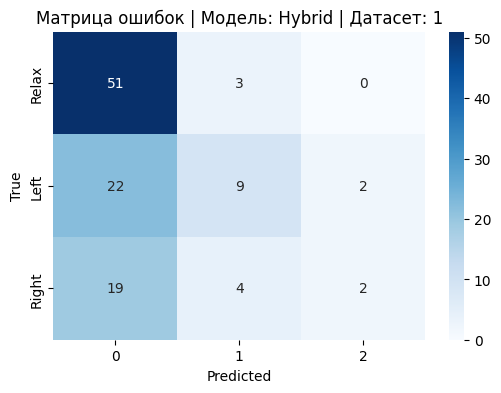

Оптимизация и обучение :  Rocket


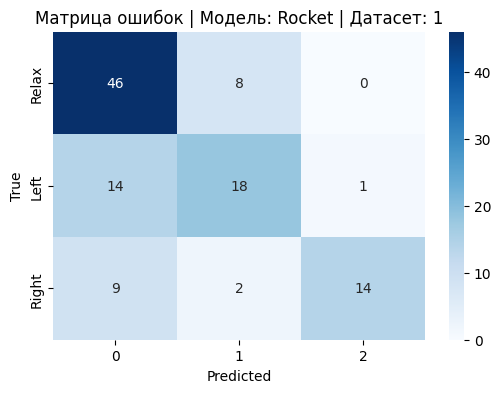

Оптимизация и обучение :  CSP_LDA
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 64 dim * 7.3e+15  max singular value)
    Estimated rank (data): 60
    data: rank 60 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 60
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 64 dim * 7.4e+15  max singular value)
    Estimated rank (data): 60
    data: rank 60 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 60
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=N

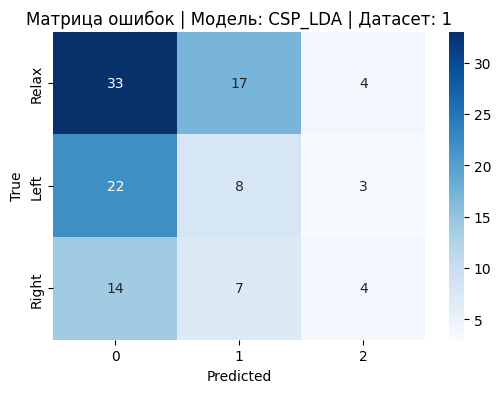

Оптимизация и обучение :  CSP_Forest
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 64 dim * 7.3e+15  max singular value)
    Estimated rank (data): 60
    data: rank 60 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 60
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 64 dim * 7.4e+15  max singular value)
    Estimated rank (data): 60
    data: rank 60 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 60
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data wi

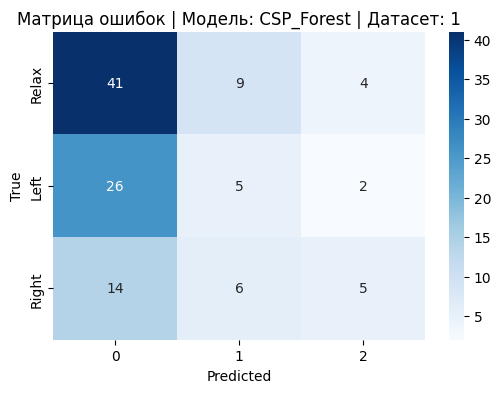

Датасет:  2
Загрузка MNE Sample
Opening raw data file C:\Users\nymphernus\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


C:\Users\nymphernus\AppData\Local\Temp\ipykernel_7964\882624364.py:14: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw_proc.resample(sfreq, verbose=False)


Всего эпох после фильтрации: 55
Классы: {np.int64(101): np.int64(29), np.int64(102): np.int64(26)}
Оптимизация и обучение :  Hybrid


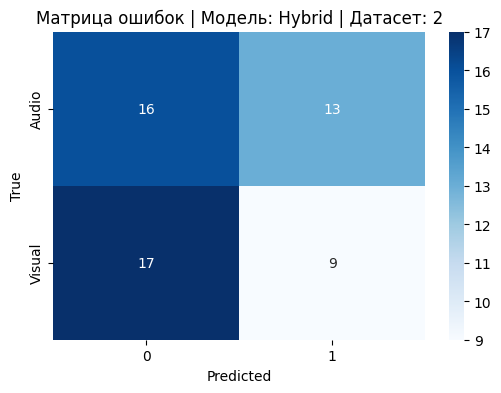

Оптимизация и обучение :  Rocket


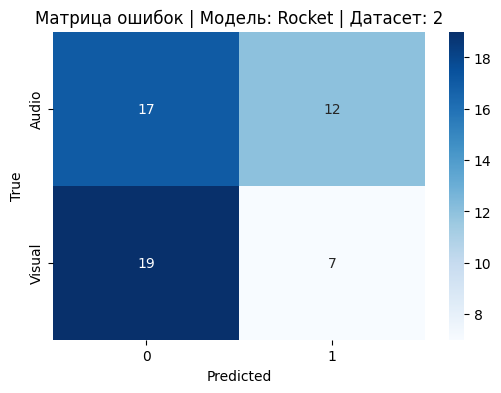

Оптимизация и обучение :  CSP_LDA
Computing rank from data with rank=None
    Using tolerance 29 (2.2e-16 eps * 59 dim * 2.2e+15  max singular value)
    Estimated rank (data): 56
    data: rank 56 computed from 59 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 59 -> 56
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 28 (2.2e-16 eps * 59 dim * 2.1e+15  max singular value)
    Estimated rank (data): 56
    data: rank 56 computed from 59 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 59 -> 56
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 29 (2.2e-16 eps * 59 dim * 2.2e+15  max singular value)
    Estimated rank (data): 56
    da

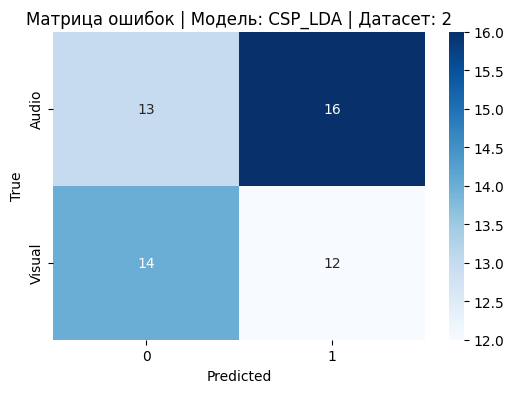

Оптимизация и обучение :  CSP_Forest
Computing rank from data with rank=None
    Using tolerance 29 (2.2e-16 eps * 59 dim * 2.2e+15  max singular value)
    Estimated rank (data): 56
    data: rank 56 computed from 59 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 59 -> 56
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 28 (2.2e-16 eps * 59 dim * 2.1e+15  max singular value)
    Estimated rank (data): 56
    data: rank 56 computed from 59 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 59 -> 56
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 29 (2.2e-16 eps * 59 dim * 2.2e+15  max singular value)
    Estimated rank (data): 56
   

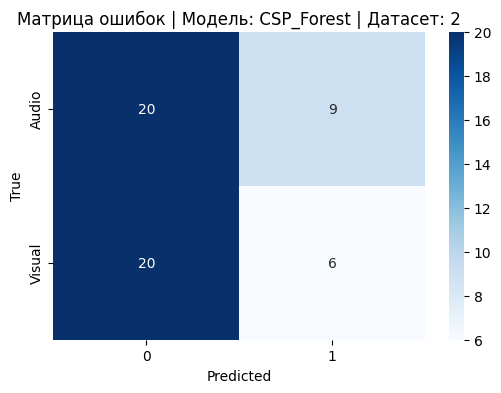

Датасет:  3
Загрузка ERP Core
Opening raw data file C:\Users\nymphernus\mne_data\MNE-ERP-CORE-data\ERP-CORE_Subject-001_Task-Flankers_eeg.fif...
    Range : 0 ... 935935 =      0.000 ...   913.999 secs
Ready.
Reading 0 ... 935935  =      0.000 ...   913.999 secs...
Всего эпох после фильтрации: 33
Классы: {np.int64(201): np.int64(16), np.int64(202): np.int64(17)}
Оптимизация и обучение :  Hybrid


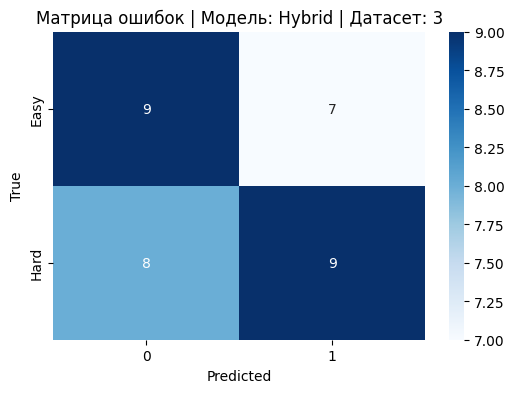

Оптимизация и обучение :  Rocket


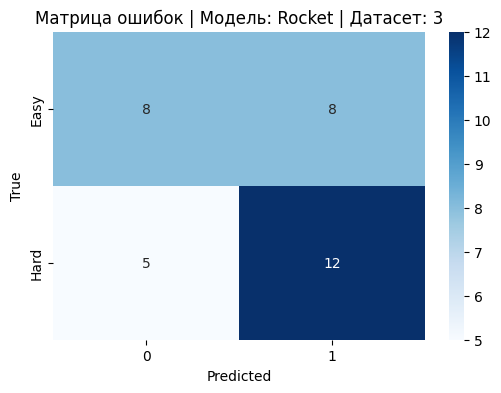

Оптимизация и обучение :  CSP_LDA
Computing rank from data with rank=None
    Using tolerance 11 (2.2e-16 eps * 30 dim * 1.7e+15  max singular value)
    Estimated rank (data): 26
    data: rank 26 computed from 30 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 30 -> 26
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 12 (2.2e-16 eps * 30 dim * 1.8e+15  max singular value)
    Estimated rank (data): 26
    data: rank 26 computed from 30 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 30 -> 26
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 11 (2.2e-16 eps * 30 dim * 1.7e+15  max singular value)
    Estimated rank (data): 26
  

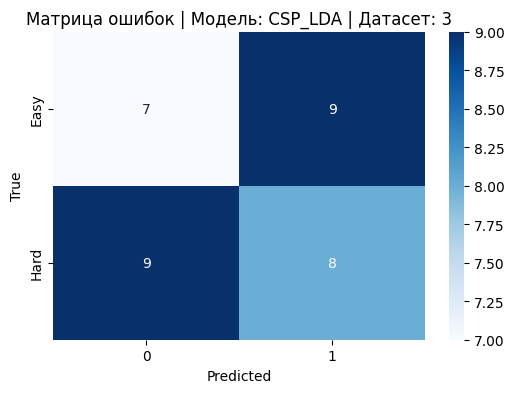

Оптимизация и обучение :  CSP_Forest
Computing rank from data with rank=None
    Using tolerance 11 (2.2e-16 eps * 30 dim * 1.7e+15  max singular value)
    Estimated rank (data): 26
    data: rank 26 computed from 30 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 30 -> 26
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 12 (2.2e-16 eps * 30 dim * 1.8e+15  max singular value)
    Estimated rank (data): 26
    data: rank 26 computed from 30 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 30 -> 26
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 11 (2.2e-16 eps * 30 dim * 1.7e+15  max singular value)
    Estimated rank (data)

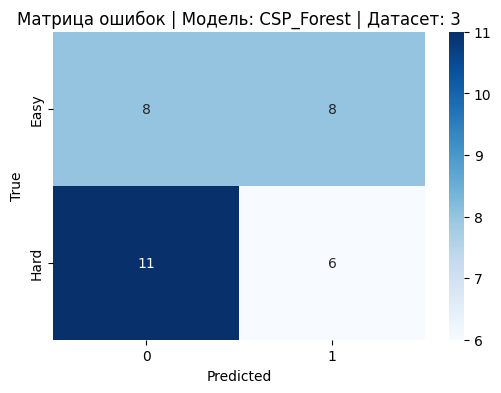

In [240]:
res = start_training([1, 2, 3], [], StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

### Вывод таблицы результатов

In [255]:
for dataset_id in sorted(res['Dataset'].unique()):
    print("Датасет :", dataset_id)
    dataset_df = res[res['Dataset'] == dataset_id].copy()
    
    dataset_df = dataset_df.set_index('Model').drop(columns=['Dataset'])
    display(dataset_df.style.set_properties(**{'text-align': 'left'}))

Датасет : 1


,Accuracy,F1_Macro,Time,Params
Model,,,,
Hybrid,0.553571,0.401303,49.080000,"{'classifier__n_estimators': 200, 'extractor__num_kernels': 100}"
Rocket,0.696429,0.679377,138.240000,{'rocket_classifier__num_kernels': 2000}
CSP_LDA,0.401786,0.334987,102.170000,"{'csp__n_components': 8, 'csp__reg': 'ledoit_wolf'}"
CSP_Forest,0.455357,0.357955,326.370000,"{'classifier__max_depth': None, 'classifier__n_estimators': 100, 'csp__n_components': 6, 'csp__reg': None}"


Датасет : 2


,Accuracy,F1_Macro,Time,Params
Model,,,,
Hybrid,0.454545,0.445565,23.880000,"{'classifier__n_estimators': 200, 'extractor__num_kernels': 100}"
Rocket,0.436364,0.417094,68.940000,{'rocket_classifier__num_kernels': 2000}
CSP_LDA,0.454545,0.454365,4.520000,"{'csp__n_components': 6, 'csp__reg': 'ledoit_wolf'}"
CSP_Forest,0.472727,0.436197,30.220000,"{'classifier__max_depth': None, 'classifier__n_estimators': 200, 'csp__n_components': 6, 'csp__reg': 'ledoit_wolf'}"


Датасет : 3


,Accuracy,F1_Macro,Time,Params
Model,,,,
Hybrid,0.545455,0.545455,13.070000,"{'classifier__n_estimators': 200, 'extractor__num_kernels': 100}"
Rocket,0.606061,0.600186,37.900000,{'rocket_classifier__num_kernels': 2000}
CSP_LDA,0.454545,0.454044,1.420000,"{'csp__n_components': 6, 'csp__reg': 'ledoit_wolf'}"
CSP_Forest,0.424242,0.422120,22.360000,"{'classifier__max_depth': None, 'classifier__n_estimators': 100, 'csp__n_components': 8, 'csp__reg': 'ledoit_wolf'}"
